In [268]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import os
from PIL import Image
from matplotlib.pyplot import GridSpec
import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF
from snntorch import utils
from sklearn.preprocessing import LabelEncoder

In [269]:
DATA_DIR = "../../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [270]:
from snntorch import spikegen

class CustomDatasetSpike(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, num_steps=4):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.num_steps = num_steps

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            img = spikegen.rate(img, num_steps=self.num_steps, gain=1)
            return img, label


In [271]:
train_df = pd.read_csv(f"{DATASET_DIR}/train1.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test1.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val1.csv")

In [272]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_566053.png,1
1,image_1260895.png,1
2,image_2675864.png,1
3,image_5798756.png,1
4,image_5737705.png,1


In [273]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

train_dataset = CustomDatasetSpike(train_df_encoded, f"{DATASET_DIR}/images", transform=transform)
val_dataset = CustomDatasetSpike(val_df_encoded, f"{DATASET_DIR}/images", transform=transform)

In [274]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [275]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [276]:
train_dataset[0][0].shape

torch.Size([4, 1, 32, 32])

### Notes
1. With initial architecture and 4 steps of training, the model achieved 0.93 accuracy on the test set.
2. 3 layer reduced the accuracy to 0.92. reverted back to 4 layers. and using 2nd conv2d output as 64 and no padding instead of 32 and using a transform normalize

In [277]:
class BasicSNN(nn.Module):
    def __init__(self, beta=1, num_steps=4, num_classes=2):
        super(BasicSNN, self).__init__()

        self.num_steps = num_steps
        self.num_classes = num_classes
        self.spike_grad = surrogate.fast_sigmoid(slope=25)

        self.conv1 = nn.Conv2d(1, 16, kernel_size=4, stride=4)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=2, stride=2)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)


        # flattened_size = 32 * (32 // 4) * (32 // 4)

        self.fc1 = nn.Linear(32, self.num_classes)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)

        self.spk1 = None
        self.spk2 = None


    def forward(self, x):
        # x shape: [batch_size, num_steps, C, H, W]
        x = x.permute(1, 0, 2, 3, 4)  # New shape: [num_steps, batch_size, C, H, W]
        
        mem1 = self.lif1.reset_mem()
        mem2 = self.lif2.reset_mem()
        mem3 = self.lif3.reset_mem()

        spk_rec = []
        mem_rec = []

        spk1_rec = []
        spk2_rec = []

        for step in range(self.num_steps):
            x_step = x[step]  # [batch_size, C, H, W] for current timestep

            # Layer 1
            cur1 = self.conv1(x_step)
            cur1 = F.max_pool2d(cur1, 2)  # Optional pooling
            spike1, mem1 = self.lif1(cur1, mem1)

            # Layer 2
            cur2 = self.conv2(spike1)
            cur2 = F.max_pool2d(cur2, 2)  # Optional pooling
            spike2, mem2 = self.lif2(cur2, mem2)

            # print(spike2.shape)
            # print(spike2.flatten(1).shape)

            # Classifier
            cur3 = self.fc1(spike2.flatten(1))
            spike3, mem3 = self.lif3(cur3, mem3)


            spk1_rec.append(spike1)
            spk2_rec.append(spike2)

            spk_rec.append(spike3)
            mem_rec.append(mem3)

        self.spk1 = torch.stack(spk1_rec, dim=0)
        self.spk2 = torch.stack(spk2_rec, dim=0)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

In [278]:
dummy = torch.randn(2, 4, 1, 32, 32)
model = BasicSNN()
out, _ = model(dummy)

model.spk1.shape, model.spk2.shape, out.shape

(torch.Size([4, 2, 16, 4, 4]),
 torch.Size([4, 2, 32, 1, 1]),
 torch.Size([4, 2, 2]))

For `torch.stack`, the `dim` affects the output of the function.
1. `dim=1` -> shape: `[batch_size, time_step, output_neurons]`
2. `dim=0` -> shape: `[time_step, batch_size, output_neurons]`
3. `dim=-1` -> shape: `[batch_size, output_neurons, time_step]`


In [279]:
def train_model(train_dataloader, val_dataloader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=None, device="cuda", dt_ms=1.0):
    # Initialize model
    model = BasicSNN(num_steps=4).to(device)
    
    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, 
                                 weight_decay=weight_decay if weight_decay else 0,
                                 betas=(0.9, 0.999))
    

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=num_epochs // 5, T_mult=1, eta_min=1e-6, last_epoch=-1)

    # Tracking lists
    train_loss_hist = []
    val_loss_hist = []    
    avg_train_loss_hist = []
    avg_val_loss_hist = []    
    train_acc_hist = []
    val_acc_hist = []

    # Spike statistics
    spike_stats = {
        'train_avg_spikes_per_neuron': [],
        'train_spike_rate_hz': [],
        'train_spike_count': [],
        'val_avg_spikes_per_neuron': [],
        'val_spike_rate_hz': [],
        'val_spike_count': [],
        'train_active_neurons_percent': [],
        'val_active_neurons_percent': [],
        'firing_rate_stability': [],
        'membrane_potential_avg': [],
        'membrane_potential_std': [],
        'threshold_proximity_avg': [],
        'threshold_proximity_std': [],
        'val_threshold_proximity_avg': [],
        'val_threshold_proximity_std': [],
    }

    best_val_loss = float('inf')
    best_model_state = None
    neuron_cache = {'layer1': None, 'layer2': None, 'output': None}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # --- TRAINING PHASE ---
        model.train()
        epoch_train_loss = 0
        epoch_spike_count = 0
        epoch_active_neurons = 0
        total_neurons = 0
        total_possible = 0
        
        # Membrane potential tracking
        train_sum_mem = 0.0
        train_sum_sq_mem = 0.0
        train_total_mem_samples = 0
        
        # Threshold proximity tracking
        train_proximity_sum = 0.0
        train_proximity_sq_sum = 0.0
        train_proximity_samples = 0

        for data, targets in tqdm(train_dataloader, desc="Training"):
            data, targets = data.to(device), targets.to(device)
            utils.reset(model)

            # Forward pass
            spk_rec, mem_rec = model(data)

            # Calculate neuron counts once
            if neuron_cache['layer1'] is None:
                with torch.no_grad():
                    neuron_cache['layer1'] = model.spk1[0, 0].numel()
                    neuron_cache['layer2'] = model.spk2[0, 0].numel()
                    neuron_cache['output'] = spk_rec.size(-1)

            # Get cached values
            nl1 = neuron_cache['layer1']
            nl2 = neuron_cache['layer2']
            no = neuron_cache['output']

            # Loss calculation
            loss = loss_fn(spk_rec, targets)
            epoch_train_loss += loss.item()
            train_loss_hist.append(loss.item())

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # --- SPIKE STATISTICS ---
            with torch.no_grad():
                spike_tensor = spk_rec.detach().to(device)
                layer1_spikes = model.spk1.detach().to(device)
                layer2_spikes = model.spk2.detach().to(device)

                # Spike counts
                batch_spike_count = (spike_tensor.sum() + layer1_spikes.sum() + layer2_spikes.sum()).item()
                epoch_spike_count += batch_spike_count

                # Neuron counts
                batch_size = data.size(0)
                time_steps = spike_tensor.size(0)
                total_batch_neurons = (nl1 + nl2 + no) * batch_size * time_steps
                total_neurons += total_batch_neurons

                # Active neurons (CORRECT implementation)
                active1 = (layer1_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active2 = (layer2_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active3 = (spike_tensor.sum(dim=0) > 0).sum(dim=1).sum().item()
                epoch_active_neurons += active1 + active2 + active3
                total_possible += (nl1 + nl2 + no) * batch_size

                # Membrane potential statistics
                if mem_rec is not None:
                    mem_tensor = mem_rec.detach()
                    train_sum_mem += mem_tensor.sum().item()
                    train_sum_sq_mem += (mem_tensor**2).sum().item()
                    train_total_mem_samples += mem_tensor.numel()

                    # Threshold proximity
                    proximity = torch.abs(mem_tensor - 0.3)  # Hardcoded threshold
                    train_proximity_sum += proximity.sum().item()
                    train_proximity_sq_sum += (proximity**2).sum().item()
                    train_proximity_samples += proximity.numel()

        # --- EPOCH STATISTICS ---
        avg_train_loss = epoch_train_loss / len(train_dataloader)
        avg_train_loss_hist.append(avg_train_loss)

        # Spike metrics
        avg_spikes_per_neuron = epoch_spike_count / total_neurons if total_neurons > 0 else 0.0
        active_percent = (epoch_active_neurons / total_possible) * 100 if total_possible > 0 else 0.0
        spike_stats['train_avg_spikes_per_neuron'].append(avg_spikes_per_neuron)
        spike_stats['train_spike_rate_hz'].append(avg_spikes_per_neuron * (1000 / dt_ms))
        spike_stats['train_spike_count'].append(epoch_spike_count)
        spike_stats['train_active_neurons_percent'].append(active_percent)

        # Membrane metrics
        if train_total_mem_samples > 0:
            avg_mem = train_sum_mem / train_total_mem_samples
            std_mem = np.sqrt((train_sum_sq_mem / train_total_mem_samples) - avg_mem**2)
        else:
            avg_mem = std_mem = 0.0
        spike_stats['membrane_potential_avg'].append(avg_mem)
        spike_stats['membrane_potential_std'].append(std_mem)

        # Threshold proximity
        if train_proximity_samples > 0:
            avg_prox = train_proximity_sum / train_proximity_samples
            std_prox = np.sqrt((train_proximity_sq_sum / train_proximity_samples) - avg_prox**2)
        else:
            avg_prox = std_prox = 0.0
        spike_stats['threshold_proximity_avg'].append(avg_prox)
        spike_stats['threshold_proximity_std'].append(std_prox)

        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Train Spikes/Neuron: {avg_spikes_per_neuron:.4f} ({avg_spikes_per_neuron*(1000/dt_ms):.1f}Hz)")
        print(f"Active Neurons: {active_percent:.1f}%")
        print("-" * 50)


        # --- VALIDATION PHASE ---
        with torch.no_grad():
            model.eval()
            val_loss = 0
            correct = 0
            total = 0
            val_spike_count = 0
            val_total_neurons = 0
            val_active_neurons = 0
            val_total_possible = 0
            
            # Membrane tracking
            val_sum_mem = 0.0
            val_sum_sq_mem = 0.0
            val_total_mem_samples = 0
            
            # Threshold proximity
            val_proximity_sum = 0.0
            val_proximity_sq_sum = 0.0
            val_proximity_samples = 0
            
            for data, targets in tqdm(val_dataloader, desc="Validation"):
                data, targets = data.to(device), targets.to(device)
                utils.reset(model)

                # Forward pass
                spk_rec, mem_rec = model(data)

                # Reuse cached values
                nl1 = neuron_cache['layer1']
                nl2 = neuron_cache['layer2']
                no = neuron_cache['output']

                # Loss and accuracy
                loss = loss_fn(spk_rec, targets)
                val_loss += loss.item()
                acc = SF.accuracy_rate(spk_rec, targets)
                correct += acc * data.size(0)
                total += data.size(0)

                # --- VALIDATION STATISTICS ---
                spike_tensor = spk_rec.detach()
                layer1_spikes = model.spk1.detach()
                layer2_spikes = model.spk2.detach()

                # Spike counts
                batch_spike = (spike_tensor.sum() + layer1_spikes.sum() + layer2_spikes.sum()).item()
                val_spike_count += batch_spike

                # Neuron counts
                batch_size = data.size(0)
                time_steps = spike_tensor.size(0)
                val_total_neurons += (nl1 + nl2 + no) * batch_size * time_steps

                # Active neurons
                active1 = (layer1_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active2 = (layer2_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active3 = (spike_tensor.sum(dim=0) > 0).sum(dim=1).sum().item()
                val_active_neurons += active1 + active2 + active3
                val_total_possible += (nl1 + nl2 + no) * batch_size

                # Membrane stats
                if mem_rec is not None:
                    mem_tensor = mem_rec.detach()
                    val_sum_mem += mem_tensor.sum().item()
                    val_sum_sq_mem += (mem_tensor**2).sum().item()
                    val_total_mem_samples += mem_tensor.numel()

                    # Threshold proximity
                    proximity = torch.abs(mem_tensor - 0.3)
                    val_proximity_sum += proximity.sum().item()
                    val_proximity_sq_sum += (proximity**2).sum().item()
                    val_proximity_samples += proximity.numel()

        # --- VALIDATION METRICS ---
        avg_val_loss = val_loss / len(val_dataloader)
        val_acc = correct / total
        avg_val_loss_hist.append(avg_val_loss)
        val_acc_hist.append(val_acc)

        # Spike metrics
        val_avg_spikes = val_spike_count / val_total_neurons if val_total_neurons > 0 else 0.0
        val_active_percent = (val_active_neurons / val_total_possible) * 100 if val_total_possible > 0 else 0.0
        spike_stats['val_avg_spikes_per_neuron'].append(val_avg_spikes)
        spike_stats['val_spike_rate_hz'].append(val_avg_spikes * (1000 / dt_ms))
        spike_stats['val_spike_count'].append(val_spike_count)
        spike_stats['val_active_neurons_percent'].append(val_active_percent)

        # Membrane metrics
        if val_total_mem_samples > 0:
            avg_val_mem = val_sum_mem / val_total_mem_samples
            std_val_mem = np.sqrt((val_sum_sq_mem / val_total_mem_samples) - avg_val_mem**2)
        else:
            avg_val_mem = std_val_mem = 0.0

        # Threshold proximity
        if val_proximity_samples > 0:
            avg_val_prox = val_proximity_sum / val_proximity_samples
            std_val_prox = np.sqrt((val_proximity_sq_sum / val_proximity_samples) - avg_val_prox**2)
        else:
            avg_val_prox = std_val_prox = 0.0
        spike_stats['val_threshold_proximity_avg'].append(avg_val_prox)
        spike_stats['val_threshold_proximity_std'].append(std_val_prox)

        # --- MODEL CHECKPOINTING ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'val_loss': best_val_loss,
                'val_acc': val_acc
            }
            print(f"New best validation loss: {best_val_loss:.4f}")

        # --- EPOCH REPORTING ---
        print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
        print(f"Val Spikes/Neuron: {val_avg_spikes:.4f} ({val_avg_spikes*(1000/dt_ms):.1f}Hz)")
        print(f"Active Neurons: Train {active_percent:.1f}% | Val {val_active_percent:.1f}%")
        print(f"Membrane Potential: Train {avg_mem:.4f} ± {std_mem:.4f} | Val {avg_val_mem:.4f} ± {std_val_mem:.4f}")
        print(f"Threshold Proximity: Train {avg_prox:.4f} ± {std_prox:.4f} | Val {avg_val_prox:.4f} ± {std_val_prox:.4f}")
        print("-" * 50)

        # Update scheduler
        scheduler.step()

    # --- FINAL SAVING ---
    history = {
        "train_loss": train_loss_hist,
        "val_loss": val_loss_hist,
        "avg_train_loss": avg_train_loss_hist,
        "avg_val_loss": avg_val_loss_hist,
        "val_acc": val_acc_hist,
        "spike_stats": spike_stats,
        "best_val_loss": best_val_loss
    }

    if model_savepath:
        # Save final model
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history
        }, model_savepath)

        # Save best model separately
        if best_model_state:
            best_path = model_savepath.replace(".pt", "_best.pt")
            torch.save(best_model_state, best_path)
            print(f"Best model (loss={best_val_loss:.4f}) saved to {best_path}")

    return model, history

In [280]:
base_dir = "../../models/checkpoints/basic_snn"
model_savepath = f"{base_dir}/model_ratev2beta1.pt"


os.makedirs(base_dir, exist_ok=True)

In [281]:
savepath = model_savepath

device = "cuda" if torch.cuda.is_available() else "cpu"

# calculate class weights
total_samples = len(train_df_encoded)
class_counts = np.bincount(train_df_encoded["Label"])
class_weights = total_samples / (len(LE.classes_) * class_counts)

class_weights = torch.as_tensor(class_weights, dtype=torch.float32).to(device)

class_weights

tensor([0.6000, 3.0000], device='cuda:0')

In [282]:
loss_fn = SF.ce_rate_loss(weight=class_weights)

In [ ]:
model, history = train_model(train_data_loader, val_data_loader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=savepath, device=device, dt_ms=1.0)

# model, history = train_model(train_data_loader_spike, val_data_loader_spike, loss_fn, lr=1e-2, weight_decay=None, num_epochs=50, model_savepath=savepath, device=device, dt_ms=1.0)

Epoch 1/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [01:30<00:00,  8.28it/s]


Train Loss: 0.7690
Train Spikes/Neuron: 0.3453 (345.3Hz)
Active Neurons: 56.2%
--------------------------------------------------


Validation: 100%|██████████| 750/750 [01:24<00:00,  8.92it/s]


New best validation loss: 0.4546
Val Loss: 0.4546 | Val Acc: 0.7753
Val Spikes/Neuron: 0.3251 (325.1Hz)
Active Neurons: Train 56.2% | Val 56.1%
Membrane Potential: Train -0.4995 ± 2.9858 | Val 0.0474 ± 2.2024
Threshold Proximity: Train 2.3153 ± 2.0478 | Val 1.7225 ± 1.3955
--------------------------------------------------
Epoch 2/50
--------------------------------------------------


...

Validation: 100%|██████████| 750/750 [01:08<00:00, 11.00it/s]


Val Loss: 0.4114 | Val Acc: 0.8397
Val Spikes/Neuron: 0.3300 (330.0Hz)
Active Neurons: Train 46.2% | Val 44.9%
Membrane Potential: Train 0.1635 ± 16.1218 | Val 0.3275 ± 13.9832
Threshold Proximity: Train 13.3098 ± 9.0982 | Val 11.3533 ± 8.1630
--------------------------------------------------
Epoch 49/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [01:28<00:00,  8.46it/s]


Train Loss: 0.6220
Train Spikes/Neuron: 0.3359 (335.9Hz)
Active Neurons: 45.6%
--------------------------------------------------


Validation:  67%|██████▋   | 500/750 [00:50<00:24, 10.37it/s]

In [ ]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

test_dataset = CustomDatasetSpike(test_data_encoded, f"{DATASET_DIR}/images", transform=transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# checkpoint = torch.load(savepath, weights_only=False)
# best_model = BasicSNN().to(device)
# best_model.load_state_dict(checkpoint['model_state_dict'])

checkpoint = torch.load(savepath, weights_only=False)
best_model = BasicSNN(num_steps=4).to(device)
best_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [ ]:
# sample 10000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(6000, random_state=42)

test_dataset_sample = CustomDatasetSpike(test_data_sample, f"{DATASET_DIR}/images", transform=transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
def calculate_accuracy2(model, test_data_loader_sample, device, class_names=None):
    y_true = torch.tensor([], dtype=torch.long, device=device)
    y_pred = torch.tensor([], dtype=torch.long, device=device)

    with torch.no_grad():
        model.eval()
        correct = 0
        total = 0

        for images, labels in tqdm(test_data_loader_sample, desc="Calculating Accuracy"):
            images, labels = images.to(device), labels.to(device)
            utils.reset(model)  # Reset neuron states per batch

            spk_rec, _ = model(images)  # Shape: [num_steps, batch_size, num_classes]
            spk_mean = spk_rec.mean(dim=0)  # Aggregate spikes over time
            preds = spk_mean.argmax(dim=1)  # Get predictions

            # Append predictions and labels
            y_true = torch.cat((y_true, labels))
            y_pred = torch.cat((y_pred, preds))

            # Compute batch accuracy
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        # Convert to numpy arrays only once
        y_true = y_true.cpu().numpy()
        y_pred = y_pred.cpu().numpy()

        # Compute overall accuracy
        acc = correct / total
        print(f"Accuracy: {acc:.4f}")

    return y_true, y_pred

def calculate_accuracy(model, data_loader, device="cuda"):
    correct = 0
    total = 0

    for data, targets in tqdm(data_loader, desc="Calculating Accuracy"):
        data, targets = data.to(device), targets.to(device)

        utils.reset(model)  # Reset neuron states per batch

        spk_rec, _ = model(data)

        # calculate accuracy
        acc = SF.accuracy_rate(spk_rec, targets)

        correct += acc * data.size(0)
        total += data.size(0)

    return correct / total


y_true, y_pred = calculate_accuracy2(best_model, test_data_loader_sample, device=device)
# Example usage
# calculate_accuracy(best_model, test_data_loader_sample, device=device)

# y_true, y_pred = calculate_accuracy2(best_model, test_data_loader_spike_sample, device=device)


Calculating Accuracy: 100%|██████████| 300/300 [00:34<00:00,  8.70it/s]

Accuracy: 0.9563


              precision    recall  f1-score   support

   Malicious       0.99      0.92      0.95      6000
      Benign       0.92      0.99      0.96      6000

    accuracy                           0.96     12000
   macro avg       0.96      0.96      0.96     12000
weighted avg       0.96      0.96      0.96     12000



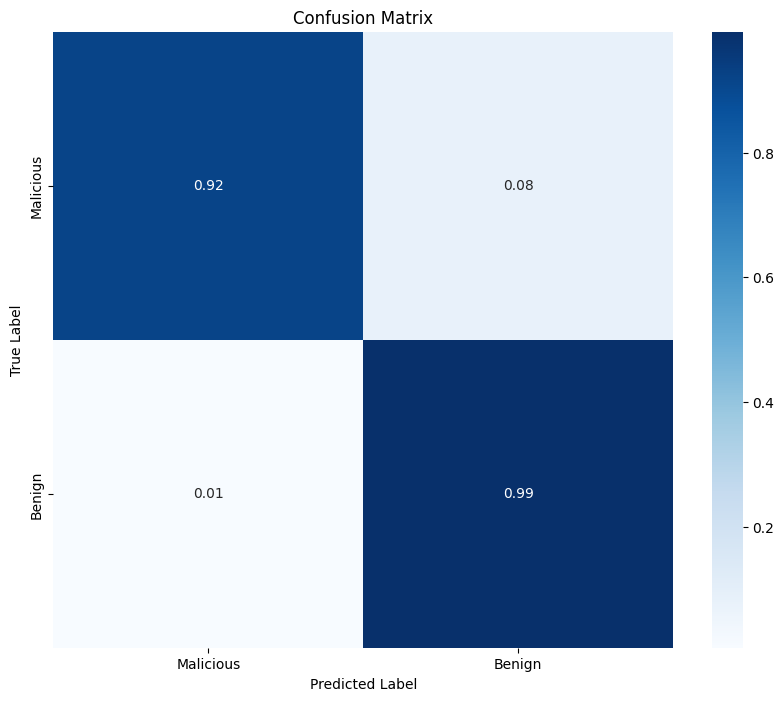

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_cm(y_true, y_pred, classes, normalize=False):
    """Plot confusion matrix."""

    classification_rep = classification_report(y_true, y_pred, target_names=classes)
    print(classification_rep)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)), normalize='true' if normalize else None)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Plot confusion matrix
plot_cm(y_true, y_pred, LE.classes_, normalize=True)

In [ ]:
# create a popup notification when the notebook run is complete
import os
os.system("notify-send 'Notebook run complete'")
